In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skopt import gp_minimize
import maxflow
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy import ndimage
from scipy.ndimage import gaussian_filter

In [10]:
!git checkout version-maxflow

error: pathspec 'version-maxflow' did not match any file(s) known to git


In [9]:
def plot_multiple(images, titles, colormap="gray", max_columns=np.inf, share_axes=True):
    """Plot multiple images as subplots on a grid."""
    assert len(images) == len(titles)
    n_images = len(images)
    n_cols = min(max_columns, n_images)
    n_rows = int(np.ceil(n_images / n_cols))
    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(n_cols * 4, n_rows * 4),
        squeeze=False,
        sharex=share_axes,
        sharey=share_axes,
    )

    axes = axes.flat
    # Hide subplots without content
    for ax in axes[n_images:]:
        ax.axis("off")

    if not isinstance(colormap, (list, tuple)):
        colormaps = [colormap] * n_images
    else:
        colormaps = colormap

    for ax, image, title, cmap in zip(axes, images, titles, colormaps):
        ax.imshow(image, cmap=cmap)
        ax.set_title(title)

    fig.tight_layout()

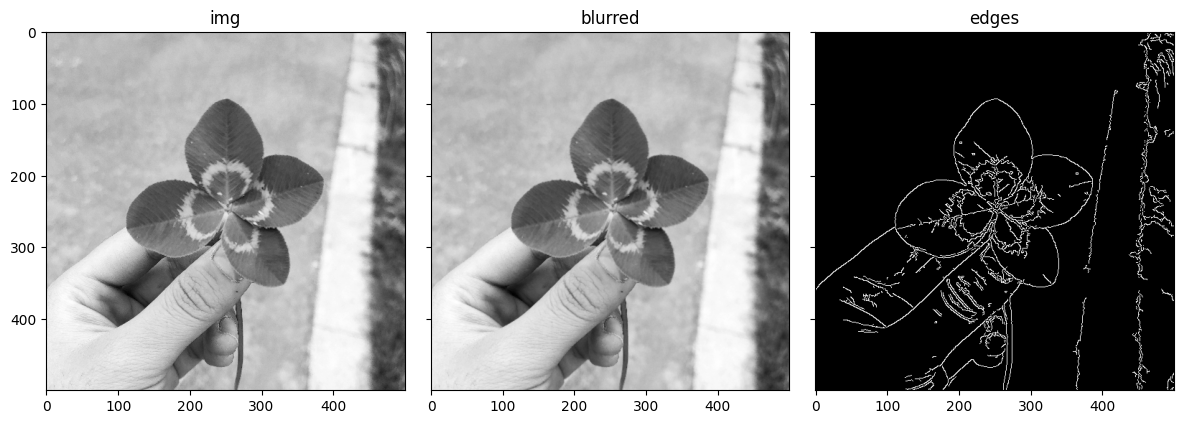

In [17]:
img = cv2.imread('four_leave_plant.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (500, 500))
blurred = cv2.GaussianBlur(img, (5, 5), 0.5)
edges = cv2.Canny(blurred, threshold1=50, threshold2=100)

plot_multiple([img, blurred, edges], ['img', 'blurred', 'edges'])

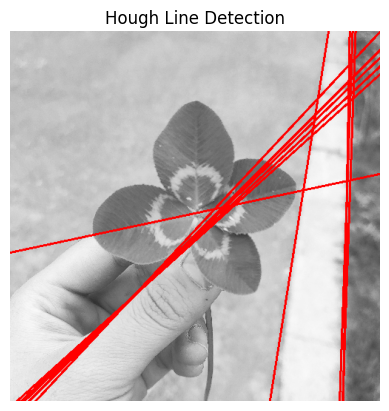

In [19]:
# Detect lines using Hough Transform
lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=100)

# Convert original to color for line drawing
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

# Draw lines
if lines is not None:
    for rho, theta in lines[:, 0]:
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        cv2.line(img_color, (x1, y1), (x2, y2), (0, 0, 255), 2)

# Show result
plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title("Hough Line Detection")
plt.show()

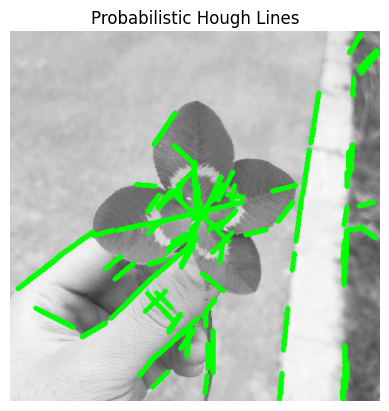

In [22]:
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=50, minLineLength=20, maxLineGap=5)
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

if lines is not None:
    for x1, y1, x2, y2 in lines[:, 0]:
        cv2.line(img_color, (x1, y1), (x2, y2), (0, 255, 0), 5)

plt.imshow(cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB))
plt.title("Probabilistic Hough Lines")
plt.axis('off')
plt.show()

In [2]:
def gauss_derivs(img, sigma):
    grad_x = gaussian_filter(img, sigma, order=[0, 1]).flatten().reshape(-1, 1)
    grad_y = gaussian_filter(img, sigma, order=[1, 0]).flatten().reshape(-1, 1)
    dxx = gaussian_filter(img, sigma, order=[2, 0]).flatten().reshape(-1, 1)
    dyy = gaussian_filter(img, sigma, order=[0, 2]).flatten().reshape(-1, 1)
    dxy = gaussian_filter(img, sigma, order=[1, 1]).flatten().reshape(-1, 1)
    return grad_x, grad_y, dxx, dyy, dxy

In [15]:
# Read and initialize
img = cv2.imread('try.png')

h, w, c = img.shape
img = cv2.resize(img, (800, int(800/w*h)))
h, w, c = img.shape
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)

dx, dy, dxx, dyy, dxy = gauss_derivs(gray, 5.0)

# plot_multiple(
#     [gray, grad_x, grad_y], 
#     ['gray scale image', 'x-derivative', 'y-derivative']
# )

rgb_flat = img.reshape(-1, 3).astype(np.float32)

features = np.hstack((rgb_flat, dx, dy, dxx, dyy, dxy))
scaler = StandardScaler()
features = scaler.fit_transform(features)

In [16]:
# # add distance to center
# yy, xx = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')
# cx, cy = h / 2, w / 2  # Image center
# distance_to_center = np.sqrt((yy - cx)**2 + (xx - cy)**2)
# distance_to_center = distance_to_center / distance_to_center.max()
# distance_to_center *= 0.05
# distance_flat = distance_to_center.flatten().reshape(-1, 1)
# features = np.hstack((features, distance_flat))

In [17]:
# initialize for drawing
fg_mask = np.zeros((h, w), dtype=np.uint8)
bg_mask = np.zeros((h, w), dtype=np.uint8) # to store your seed strokes for foreground and background.

drawing = False
current_label = 'fg'  # or 'bg'

In [18]:
# def drawing func
def draw_seed(event, x, y, flags, param):
    global drawing, fg_mask, bg_mask, current_label

    if event == cv2.EVENT_LBUTTONDOWN:
        drawing = True
    elif event == cv2.EVENT_MOUSEMOVE and drawing:
        if current_label == 'fg':
            cv2.circle(fg_mask, (x, y), 10, 255, -1)
        elif current_label == 'bg':
            cv2.circle(bg_mask, (x, y), 10, 255, -1)
    elif event == cv2.EVENT_LBUTTONUP:
        drawing = False

In [19]:
# Window for drawing
cv2.namedWindow("Draw (press 'f' or 'b', then draw)")
cv2.setMouseCallback("Draw (press 'f' or 'b', then draw)", draw_seed)

print("Instructions:")
print(" - Press 'f' to draw foreground seeds")
print(" - Press 'b' to draw background seeds")
print(" - Press 's' to segment")
print(" - Press 'q' to quit")

while True:
    preview = img.copy()
    preview[fg_mask > 0] = [255, 255, 255]    # white = foreground
    preview[bg_mask > 0] = [0, 0, 0]      # black = background
    cv2.imshow("Draw (press 'f' or 'b', then draw)", preview)

    key = cv2.waitKey(1) & 0xFF
    if key == ord('f'):
        current_label = 'fg'
        print("Drawing: foreground")
    elif key == ord('b'):
        current_label = 'bg'
        print("Drawing: background")
    elif key == ord('s'):
        break
    elif key == ord('q'):
        cv2.destroyAllWindows()
        exit()

cv2.destroyAllWindows()

Instructions:
 - Press 'f' to draw foreground seeds
 - Press 'b' to draw background seeds
 - Press 's' to segment
 - Press 'q' to quit
Drawing: background


In [20]:
# Mixture of Gaussian model
fg_inds = np.where(fg_mask.flatten() > 0)[0]
bg_inds = np.where(bg_mask.flatten() > 0)[0]
fg_pixels = features[fg_inds]
bg_pixels = features[bg_inds]


lowest_bic = np.inf
best_n = 1
bic_list = []

# for n in range(7, 12):
#     gmm = GaussianMixture(n_components=n, covariance_type='full')
#     gmm.fit(bg_pixels)
#     bic = gmm.bic(bg_pixels)
#     bic_list.append(bic)
#     if bic < lowest_bic:
#         lowest_bic = bic
#         best_n = n

# print("Best n_components:", best_n)

# Fit GMMs
gmm_fg = GaussianMixture(n_components=5, covariance_type='full')
gmm_bg = GaussianMixture(n_components=5, covariance_type='full')

gmm_fg.fit(fg_pixels)
gmm_bg.fit(bg_pixels)

GaussianMixture(n_components=5)

In [21]:
# Build graph
g = maxflow.Graph[float]()
nodeids = g.add_grid_nodes((h, w))

In [22]:
# Data term (terminal edges)

fg_prob = np.exp(gmm_fg.score_samples(features))
bg_prob = np.exp(gmm_bg.score_samples(features))

fg_prob = fg_prob.reshape(h, w)
bg_prob = bg_prob.reshape(h, w)

fg_cost = -np.log(bg_prob)
bg_cost = -np.log(fg_prob)

fg_cost = np.where(fg_mask > 0, 1e9, fg_cost)  # Set fg_cost to 1e9 where fg_mask > 0
bg_cost = np.where(bg_mask > 0, 1e9, bg_cost)  # Set bg_cost to 1e9 where bg_mask > 0
bg_cost = np.where(fg_mask > 0, 0, bg_cost)
fg_cost = np.where(bg_mask > 0, 0, fg_cost)

# # Flatten the nodeids, fg_cost, and bg_cost arrays for processing all pixels at once
nodeids_flat = nodeids.flatten()
fg_cost_flat = fg_cost.flatten()
bg_cost_flat = bg_cost.flatten()

# # Add terminal edges for all pixels at once
for nid, fgc, bgc in zip(nodeids_flat, fg_cost_flat, bg_cost_flat):
    g.add_tedge(nid, fgc, bgc)

C:\Users\nujiz\AppData\Local\Temp\ipykernel_31648\3245407117.py:9: RuntimeWarning: divide by zero encountered in log
  fg_cost = -np.log(bg_prob)
C:\Users\nujiz\AppData\Local\Temp\ipykernel_31648\3245407117.py:10: RuntimeWarning: divide by zero encountered in log
  bg_cost = -np.log(fg_prob)


In [23]:
# # smoothness with constant edges
# structure = np.array([[0, 1, 0],
#                       [1, 0, 1],
#                       [0, 1, 0]], dtype=np.int32)
# g.add_grid_edges(nodeids, weights=50.0, structure=structure, symmetric=True)

In [24]:
# smoothness with gaussian distribution
img_features = features.reshape(h, w, -1)

img_down = img_features[:-1, :]     # All pixels except last row
img_right = img_features[:, :-1]    # All pixels except last column

img_curr_v = img_features[1:, :]    # Vertically below neighbors
img_curr_h = img_features[:, 1:]    # Horizontally right neighbors

# Vectorized Euclidean distance in RGB space
diff_v = np.linalg.norm(img_down - img_curr_v, axis=2)
diff_h = np.linalg.norm(img_right - img_curr_h, axis=2)

def gaussian_color_diff(d, sigma=30.0):
    return np.exp(-d**2 / (2 * sigma**2))

weights_v = gaussian_color_diff(diff_v)
weights_h = gaussian_color_diff(diff_h)

for y in range(h - 1):
    for x in range(w):
        weight = weights_v[y, x]
        g.add_edge(nodeids[y, x], nodeids[y + 1, x], weight, weight)

for y in range(h):
    for x in range(w - 1):
        weight = weights_h[y, x]
        g.add_edge(nodeids[y, x], nodeids[y, x + 1], weight, weight)

In [25]:
# Run maxflow
g.maxflow()
segments = g.get_grid_segments(nodeids)
mask = np.logical_not(segments).astype(np.uint8)

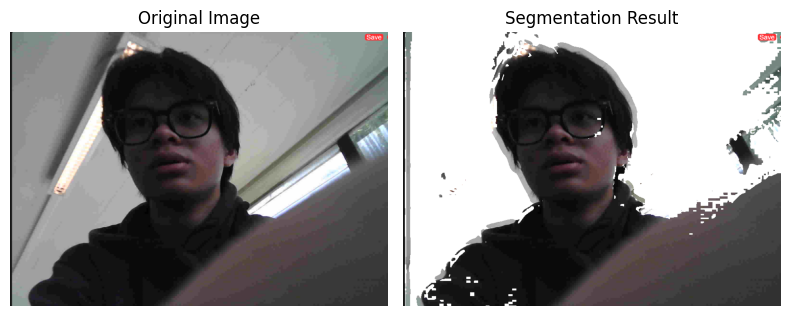

In [26]:
# Show results
fig, axs = plt.subplots(1, 2, figsize=(8, 4))

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[0].axis('off')

result_rgb = img.copy()
result_rgb[mask == 0] = [255, 255, 255]
axs[1].imshow(result_rgb)
axs[1].set_title("Segmentation Result")
axs[1].axis('off')

plt.tight_layout()
plt.show()